# Introduction: What is Transfer Learning and Why Use It

## What is transfer learning?

Computer vision

A lot of people train their model with IMAGENET What if we could use those patterns in that NN that it is trained on a million images and then customize those patterns for our own problem. That is an example for transfer learning. We take what one model have learned, for example a computer vision model, on a large dataset like ImageSet. And the customize for your own use case

Natural language processing

What if we have NN that it is train with all of wikipedia, to create a language model. We could use what that model haa learn about the structure og language itself.

The main take away is we take what one model has learned on one dataset, usually a large dataset.

So, a model wil learn patterns/weights from similar problem space.
Then Patterns get used/tuned to specific problem.

## Why use transfer leaning?

* Can leverage an existing neural network architecture proven to work on problems similar to our own.
* Can leverage a working network architecture wich has already learned patterns on similar data to our own (often results in great results with less data)

Learn patterns in a wide variety of images(using ImageNet) -> Pretrained EfficientNet architecture (already works really well on computer visiontasks). we might what to extract those pre-trained patterns from efficientnet and tuen them->Extract/tune patterns/weights to suit our own problem.

**Model performs better than from scratch**

# Where Can You Find Pretrained Models and What We Are Going to Cover

**...Suddenly lots more people can do world-class work with less resources and less data** - Jeremy Howard

Where to find pretrained models?

* Pytorch Domains libraries https://docs.pytorch.org/vision/main/models.html
* Torch image models (timm library)
* HuggingFace Hub
* Paperswithcode SOTA

## What we are going to cover?

* Getting setup (importing previously code)
* Introduce transfer learning with PyTorch
* Customise a pretrained model for our own use case.
* Evaluating a transfer learning model
* Making predictions on our own custom data



Installing the Latest Versions of Torch and Torchvision

The main course of this notebook is from Zero To Mastery academy. Here you can find my personal keynotes for my better understanding.

# 06. PyTorch Transfer Learning

What is transfer learning?

Transfer learning involves talking the parameters of what one model has learned on another dataset and applying to our own problem.

* Pretrained model = foundantion models

We are going to connect to the Multi-Weight support API. This would enable us to use multiple different models, when it says **Pre-traiend weights** thay have patterns that a model has learned on another dataset.
So for example TorchVision's New Multi-weight suppor API allows us to use multiple of the same architecture with different weight set up.

In [1]:
# Check the pytorch version you are using
import torch
import torchvision

print(torch.__version__)
print(torchvision.__version__)

2.8.0+cu126
0.23.0+cu126


Downloading Our Previously Written Code from Going Modular

Now we've got the version of torch and torchvision, we're after, let's import the code we've writtern in previous sections so that we don't have to write it all again.

In [2]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to get torchinfo, install it if it doesn't work
try:
    from torchinfo import summary
except:
    print("[INFO] Couldn't find torchinfo... installing it.")
    !pip install -q torchinfo
    from torchinfo import summary

# Try to import the going_modular directory, download it from GitHub if it doesn't work
try:
    from Going_modular.going_modular import data_setup, engine
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")
    !git clone https://github.com/sebastianperezv/PyTorch_DeepLearning
    !mv PyTorch_DeepLearning/Going_Modular .
    !rm -rf PyTorch_DeepLearning
    from Going_Modular.going_modular import data_setup, engine

[INFO] Couldn't find torchinfo... installing it.
[INFO] Couldn't find going_modular scripts... downloading them from GitHub.
Cloning into 'PyTorch_DeepLearning'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 73 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 25.66 MiB | 15.27 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [3]:
# Set up device agnostic code
device = 'cuda' if torch.cuda.is_available() else 'cpu'
device

'cuda'

Downloading Pizza, Steak, Sushi Image Data from Github

## 1. Get data

We need our pizza, steak,sushi data to build a transfer learning model on.

In [4]:
import os
import zipfile

from pathlib import Path

import requests

# Setup data path
data_path = Path('data/')
image_path = data_path / 'pizza_steak_sushi' # images from a subset of classes from the Food101 dataset

# if the image folder does not exit, download it and prepare it...
if image_path.is_dir():
  print(f'{image_path} directory exists, skipping re-download.')
else:
  print(f'Did not find {image_path}, downlaoding it...')
  image_path.mkdir(parents=True, exist_ok=True)

  # Download pizza, steak, sushi data
  with open(data_path / 'pizza_steak_sushi.zip', 'wb') as f:
    request = requests.get('https://github.com/mrdbourke/pytorch-deep-learning/raw/main/data/pizza_steak_sushi.zip')
    print('Downloading pizza, steak, sushi data...')
    f.write(request.content)

    # unzip pizza, steak, sshi data
    with zipfile.ZipFile(data_path / 'pizza_steak_sushi.zip', 'r') as zip_ref:
      print('Unzipping pizza, steak, sushi data...')
      zip_ref.extractall(image_path)

    # Remove .zip file
    os.remove(data_path / 'pizza_steak_sushi.zip')


Did not find data/pizza_steak_sushi, downlaoding it...
Unzipping pizza, steak, sushi data...


In [5]:
# Setup directory path
train_dir = image_path / 'train'
test_dir = image_path / 'test'
train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

Turning Our Data into DataLoaders with Manually Created Transforms

## 2. Create Datasets and DataLoaders

Now we have got some data, want to turn it into PyTorch DataLoaders.
To do so, we can use `data_setup.py` and the `create_dataloaders()` functions we made in Going_modular section.

There is one thing we have to think about when loading: how to **transform** it?

And with `torchvision` 0.13+ there is two way to do this:

1. Manually created transforms - you define what transforms you want your data to go through.
2. Automatically created transforms - the transforms for your data are defined by the mode you'd like to use.

Important point: when using a pretrained model, it's important that the data (including your custom data) that you pass through it is **transformed** in the same way that the data model was trained on.




### 2.1 Creating a transform for `torchvision.models` (manual creation)

`torchvision.models` contains pretrained models (models ready for transfer learning) right within `torchvision`

You have to make sure you input data regardless is text, image or audio it is transform in the way your pre-trained model is.

> All pre-trained models expect input images normalized in the same way, i.e. mini-batches of 3-channel RGB images of shape (3 x H x W), where H and W are expected to be at least 224. The images have to be loaded in to a range of [0, 1] and then normalized using mean = [0.485, 0.456, 0.406] and std = [0.229, 0.224, 0.225].

In [6]:
# Format you data so that it has the same distribution and mean
# we want that our data have the same std and mean
# this values are for each color channel
# what we are doing here is formating our own custom data to be on the same
# format as the models that we are about to use has been trained on
from torchvision import transforms
normalize = transforms.Normalize(mean=[0.485, 0,456, 0.406],
                                std=[0.229, 0.224, 0.225])

manual_transforms = transforms.Compose([
    transforms.Resize([224, 224]), # resize image to 224, 224 (height x width)
    transforms.ToTensor(), # get images into iamges 0 and 1
    normalize # make sure images have the same distribution as ImageNet (where our pre model have been trained)
])

In [7]:
from Going_Modular.going_modular import data_setup
train_dataloader, test_dataloader, class_names = data_setup.create_dataloader(train_dir=train_dir,
                                                                              test_dir=test_dir,
                                                                              transform=manual_transforms,
                                                                              batch_size=32)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7dc301519580>,
 ['pizza', 'steak', 'sushi'])

We manually have construct the transform by putting together a pipeline. If we transform our data in a way that it is different to our pre-trained model, we might get performance degradation.

now we are going to see automatically transofrms.

Turning Our Data into DataLoaders with Automatic Created Transforms

### 2.2 Creating a transform for `torchvision.models` (auto creation)

As of `torchvision` v0.13+ there is now support for automatic data transform creation based on the pretrained model weights you are using.

https://docs.pytorch.org/vision/main/models.html#initializing-pre-trained-models

In [8]:
import torchvision
torchvision.__version__

'0.23.0+cu126'

In [9]:
# Get a set of pretrained model weights
# https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b0.html#torchvision.models.efficientnet_b0
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # 'DEFAULT' = best available weights
weights

EfficientNet_B0_Weights.IMAGENET1K_V1

In [10]:
# Get the transforms used to create our pretrained weights
auto_transforms = weights.transforms()
auto_transforms

ImageClassification(
    crop_size=[224]
    resize_size=[256]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BICUBIC
)

In [11]:
# create DataLoader using automatic transforms
from Going_Modular.going_modular import data_setup

train_dataloader, test_dataloader, class_names = data_setup.create_dataloader(train_dir,
                                                                               test_dir=test_dir,
                                                                               transform=auto_transforms,
                                                                               batch_size=32)
train_dataloader, test_dataloader, class_names

(<torch.utils.data.dataloader.DataLoader at 0x7dc30151acf0>,
 ['pizza', 'steak', 'sushi'])

Which Pretrained Model Should You Use

## 3. Getting a Pre-trained model

There are various places to get a pretrained model, such as:
1. PyTorch domain libraries
2. Libraries like `timm` (torchimage models)
3. HuggingFace Hub (for plenty of different models)
4. Paperswithcode (for models across different problem spaces/domains) (This now is Hugging Face)

### 3.1 Wich pretrained model should you use?

* Experiment, experiment, experiment!

The whole idea of transfer learning: take an already wee-performing model from a problem space similar to your own and the customize to your own problem.

Three things to consider:
1. Speed - how fast does it run?
2. Size - how big is the model?
3. Performance - how well does it go on your chosen problem (e.g. how well does it classify food images? for FoodVision Mini)

Where does the model live?

Is it on device? (like a self-driving car)

Or does it live on a server?

Loking at https://docs.pytorch.org/vision/main/models.html#table-of-all-available-classification-weights

Wich model should we choose?

We want best performance (ACC@1) with the lowest numeber of parameters (Params)

For our case (deploying FoodVision Mini on a mobile device), it looks like EffNetB0 is one of our best options in terms performance vs size.

However, in light of The Bitter Lesson, if we had infinite compute, we'd likely pick the bigest model + most parameters + most general we could.

The bigger your model get hte more advanced the hardware needs ti be to store it.

Setting Up a Pretrained Model with Torchvision

### 3.2 Setting up a pretrained model

Want to create an instance of pretrained EffNetB0 - https://docs.pytorch.org/vision/main/models/generated/torchvision.models.efficientnet_b0.html#efficientnet-b0

In [12]:
# OLD method of creating a pretrained model (prior to torchvision v0.13)
# model = torchvision.models.efficientnet_b0(pretrained=True)

# New method of creating a pretrained model (torchvision v.013+)
weights = torchvision.models.EfficientNet_B0_Weights.DEFAULT # ".DEFAULT" = best available weights
model = torchvision.models.efficientnet_b0(weights=weights).to(device)
model

Downloading: "https://download.pytorch.org/models/efficientnet_b0_rwightman-7f5810bc.pth" to /root/.cache/torch/hub/checkpoints/efficientnet_b0_rwightman-7f5810bc.pth


100%|██████████| 20.5M/20.5M [00:00<00:00, 73.1MB/s]


EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [13]:
# we need to modify the in_features and out_features
# we only have three classes
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

Different Kinds of Transfer Learning

The model we are going to use is EfficientNet **feature extractor**. What this model does:

1. Extracts features from image
2. Turns features into a feature vector (by taking the average). It compress all the information that our base layers have extracted from the image into one single vector.
3. Turns feature vector into prediction logits
4. Can adjust depending on the number of classes you have.

The main idea is that the base layer, the feature extracted layers, stays frozen and we customize the input data and the output data.

With **feature extraccion** we only change the base dataset and the output layer.

With **Fine Tuning** we can unfreeze some of the base layer and update their weights to suit out custom data. This usally works well with large amount of data. Otherwise is best to just keep the base layer frozen and do Feature extraction.

Getting a Summary of the Different Layers of Our Model

### 3.3 Getting a summary of our model with `torchinfo`

torchinfo would give us more information, detail about whats happening with our model.

In [14]:
# Print a summary with torchinfo
from torchinfo import summary

summary(model=model,
        input_size=(1, 3, 224, 224), # Example of 1 image [batch_size, color_channels, height, width]
        col_names=['input_size', 'output_size', 'num_params', 'trainable'],
        col_width=20,
        row_settings=['var_names'])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 1000]            --                   True
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   True
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   True
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    864                  True
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    64                   True
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 16, 112,

This current modelhas 1000 classes.
We want to modify the Trainable params.

We want to freeze this layers (in the middle), use those patterns that our model has learned from ImageNet and then we want to change the classifier head to suit our own problem.

Freezing the Base Layers of Our Model and Updating the Classifier Head

### 3.4 Freezing the base model and changing the output layer to suit our needs

With a feature extractor model, typically you will 'freeze' the base layers of a pretrained/foundation model and update the output layers to suit your own problem.

In [15]:
model.features.parameters()

<generator object Module.parameters at 0x7dc2f68d7e60>

In [16]:
# Freeze all of the base layer in EffNetB0
# we would like to freeze all of this layers we dont want them to be
# updated during training when we are training on our data
# because we are using the weights that this layers have already learned
# from imagenet
for param in model.features.parameters():
  # print(param)
  param.requires_grad = False # PyTorch wont track the gradients of the parameters
  # and wont update them with the optimizer during training

In [17]:
model.classifier

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=1000, bias=True)
)

In [18]:
# Update the classifier head of our model to suit our problem
from torch import nn

torch.manual_seed(91)
torch.cuda.manual_seed(91)

model.classifier = nn.Sequential(
    nn.Dropout(p=0.2, inplace=True), # some neurons tuns off to learn better patterns
    nn.Linear(in_features=1280, # Feature vector coming in, this is the output from the classifier
              out_features=len(class_names))
)

model.classifier, len(class_names)

(Sequential(
   (0): Dropout(p=0.2, inplace=True)
   (1): Linear(in_features=1280, out_features=3, bias=True)
 ),
 3)

In [19]:
# Now let's see how it goes
summary(model=model,
        input_size=(1, 3, 224, 224), # Example of 1 image [batch_size, color_channels, height, width]
        col_names=['input_size', 'output_size', 'num_params', 'trainable'],
        col_width=20,
        row_settings=['var_names'])

Layer (type (var_name))                                      Input Shape          Output Shape         Param #              Trainable
EfficientNet (EfficientNet)                                  [1, 3, 224, 224]     [1, 3]               --                   Partial
├─Sequential (features)                                      [1, 3, 224, 224]     [1, 1280, 7, 7]      --                   False
│    └─Conv2dNormActivation (0)                              [1, 3, 224, 224]     [1, 32, 112, 112]    --                   False
│    │    └─Conv2d (0)                                       [1, 3, 224, 224]     [1, 32, 112, 112]    (864)                False
│    │    └─BatchNorm2d (1)                                  [1, 32, 112, 112]    [1, 32, 112, 112]    (64)                 False
│    │    └─SiLU (2)                                         [1, 32, 112, 112]    [1, 32, 112, 112]    --                   --
│    └─Sequential (1)                                        [1, 32, 112, 112]    [1, 1

Now only 3,843 parameters are trainable and thats the linear output layer.

Training Our First Transfer Learning Feature Extractor Model

## 4. Train model

In [20]:
# define loss and optimizer
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

We have `engine.py` wich contrain the train function. This is going to leverage `test_step` and `train_step`

In [21]:
# Import train function
from Going_Modular.going_modular import engine

# Set manual seed if you want
torch.manual_seed(91)
torch.cuda.manual_seed(91)

from timeit import default_timer as timer
start_time = timer()

# Setup training and sace the results
results = engine.train(model=model,
                       train_dataloader=train_dataloader,
                       test_dataloader=test_dataloader,
                       optimizer=optimizer,
                       loss_fn=loss_fn,
                       epochs=32,
                       device=device)

# End the timer and print out how long it took
end_time = timer()
print(f'[INFO] Total training time: {end_time-start_time:.3f} seconds')

  0%|          | 0/32 [00:00<?, ?it/s]

Epoch: 1 | train_loss: 1.0410 | train_acc: 0.4297 | test_loss: 0.8159 | test_acc: 0.8447
Epoch: 2 | train_loss: 0.8915 | train_acc: 0.6172 | test_loss: 0.6924 | test_acc: 0.8759
Epoch: 3 | train_loss: 0.7923 | train_acc: 0.7461 | test_loss: 0.7096 | test_acc: 0.7955
Epoch: 4 | train_loss: 0.7308 | train_acc: 0.7344 | test_loss: 0.7266 | test_acc: 0.7727
Epoch: 5 | train_loss: 0.5874 | train_acc: 0.9219 | test_loss: 0.5873 | test_acc: 0.8456
Epoch: 6 | train_loss: 0.5683 | train_acc: 0.8984 | test_loss: 0.5501 | test_acc: 0.8456
Epoch: 7 | train_loss: 0.5214 | train_acc: 0.7812 | test_loss: 0.5419 | test_acc: 0.8561
Epoch: 8 | train_loss: 0.5432 | train_acc: 0.7773 | test_loss: 0.5100 | test_acc: 0.8456
Epoch: 9 | train_loss: 0.5420 | train_acc: 0.7891 | test_loss: 0.5091 | test_acc: 0.8153
Epoch: 10 | train_loss: 0.4713 | train_acc: 0.8125 | test_loss: 0.5162 | test_acc: 0.8769
Epoch: 11 | train_loss: 0.4585 | train_acc: 0.8398 | test_loss: 0.5091 | test_acc: 0.8153
Epoch: 12 | train_l

Plotting the Loss Curves of Our Transfer Learning Model

## 5. Evaluate model by plotting loss curves

In [22]:
# Continue with regular imports
import matplotlib.pyplot as plt
import torch
import torchvision

from torch import nn
from torchvision import transforms

# Try to import the plot_loss_curves, download it from GitHub if it doesn't work
try:
    from PyTorch_Custom_Datasets.going_modular import plot_loss_curves
except:
    # Get the going_modular scripts
    print("[INFO] Couldn't find going_modular scripts... downloading them from GitHub.")
    !git clone https://github.com/sebastianperezv/PyTorch_DeepLearning
    !mv PyTorch_DeepLearning/PyTorch_Custom_Datasets .
    !rm -rf PyTorch_DeepLearning
    from PyTorch_Custom_Datasets.going_modular import plot_loss_curves

[INFO] Couldn't find going_modular scripts... downloading them from GitHub.
Cloning into 'PyTorch_DeepLearning'...
remote: Enumerating objects: 73, done.
remote: Counting objects: 100% (73/73), done.
remote: Compressing objects: 100% (64/64), done.
remote: Total 73 (delta 11), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (73/73), 25.66 MiB | 19.20 MiB/s, done.
Resolving deltas: 100% (11/11), done.


In [23]:
results.keys()

dict_keys(['train_loss', 'train_acc', 'test_loss', 'test_acc'])

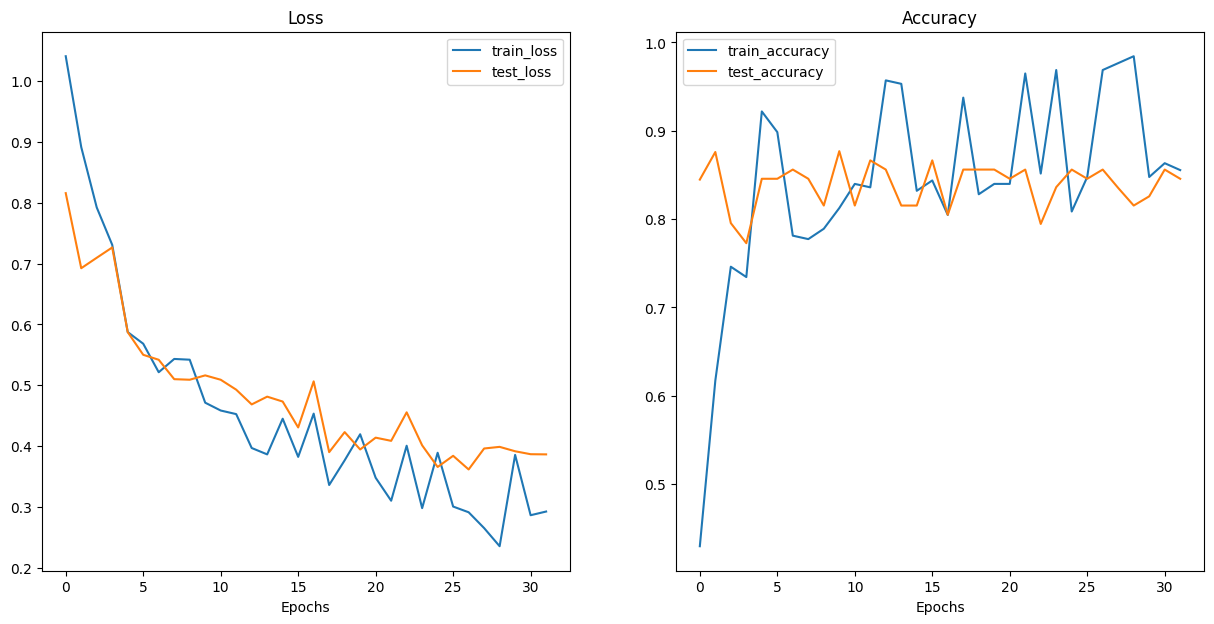

In [24]:
plot_loss_curves.plot_loss_curves(results)

What do our loss curves look like in terms o the ideal loss curve?

See here for more: https://www.learnpytorch.io/04_pytorch_custom_datasets/#8-what-should-an-ideal-loss-curve-look-like

Outlining the Steps to Make Predictions on the Test Images

## 6. Make predictions on images from the test set

Let's ad here to the data explorer's motto of visualize!

And make some qualitative predictions on our test set.

Some things to keepin mind when making predictions/inference on test data/custom data.

We have to make sure that our test/custom data is:
* Same shape - images need to be same shape as model was trained on.
* Same datatype - custom data should be in the same data type
* Same device - custom data/test data should be on the same device as the model
* Same transform - if you transform your custom data, ideally you will transform the testdata and custom data the same

To do all of this automagically, let's create a function called `pred_and_plot_image()`

1. Take in a trained mode, a list of class names, a filepath to a target image, an image size, a transform and a target device
2. Open the image with `PIL.Image.Open()`
3. Create a transform if one doesn't exist
4. Make sure the model is on the target device
5. Turn the model to `model.eval()` mode to make sure it's ready for inference (this will turn off things like `nn.Dropout()`) - Dropout helps prevent overfitting.
6. Transform the traget image and make sure its dimensionality is suited for the model (this mainly relates to batch size)
7. Make a prediction on the image by passing to the model
8. Convert the model's output logits to prediction probabilities using `torch.softmax()`
9. Convert model's prediction probabilities to prediction labels using `torch.argmax()`
10. Plot the image with `matplotlib` and set the title to the prediction label from step 9 and prediction probability from step 8.

Creating a Function Predict On and Plot Images

In [25]:
from typing import List, Tuple

from PIL import Image

from torchvision import transforms

# 1. Take in a trained model
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str],
                        image_size: Tuple[int, int] = (224, 224),
                        transform: torchvision.transforms = None,
                        device: torch.device = device):
  # 2. Open the image with PIL
  img = Image.open(image_path)

  # 3. Create a transform if ione does not exist
  if transform is not None:
    image_transform = transform
  else:
    image_transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

  ### Predict on image ###
  # 4. Make sure the model is on the target device
  model.to(device)

  # 5. Turn on inference mode and eval mode
  model.eval() # will turn off things like droput
  with torch.inference_mode():
    # 6. Transform the image and add an extra batch dimension
    # our model expect a batch dimension
    transformed_image = image_transform(img).unsqueeze(dim=0) # shape of [batch_size, color_channels, height, width]

    # 7. Make a prediction on the transformed image by passing it ti the model (also ensure it's on the target device)
    target_image_pred = model(transformed_image.to(device)) # this is an output logits

  # 8. Convert the model's output logits to pred probs
  target_image_pred_probs = torch.softmax(target_image_pred, dim = 1)
  print(target_image_pred_probs)

  # 9. Conver the model's pred probs to pred label
  target_image_pred_label = torch.argmax(target_image_pred_probs, dim = 1)

  # 10. Plot iamge with predicted label probability
  plt.figure()
  plt.imshow(img)
  plt.title(f'Pred: {class_names[target_image_pred_label]} | Prob: {target_image_pred_probs.max():.3f}')
  plt.axis(False)

Making and Plotting Predictions on Test Images

In [26]:
# Get a random list of image paths from the test set
import random
num_images_to_plot = 3
# we are going to match this file path (test_dir) for
# First * = pizza folder, steak folder or sushi folder
# Second * = anything that ends with ".jpg"
test_image_path_list = list(Path(test_dir).glob("*/*.jpg"))
# let's have a look
test_image_path_list

[PosixPath('data/pizza_steak_sushi/test/pizza/3475871.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2003290.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2019408.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/195160.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/3092704.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2236338.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2871261.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2508636.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2124579.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/194643.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/416067.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/714866.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1687143.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/398345.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/2218680.jpg'),
 PosixPath('data/pizza_steak_sushi/test/pizza/1925494.jpg'),
 PosixPath('data/pizza_steak_

In [27]:
# let's randomly select one of those
test_image_path_sample = random.sample(population=test_image_path_list,
                                       k=num_images_to_plot)
test_image_path_sample

[PosixPath('data/pizza_steak_sushi/test/pizza/2111981.jpg'),
 PosixPath('data/pizza_steak_sushi/test/sushi/2521706.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/502076.jpg')]

tensor([[0.9848, 0.0037, 0.0115]], device='cuda:0')
tensor([[0.2281, 0.0820, 0.6898]], device='cuda:0')
tensor([[0.0237, 0.9748, 0.0015]], device='cuda:0')


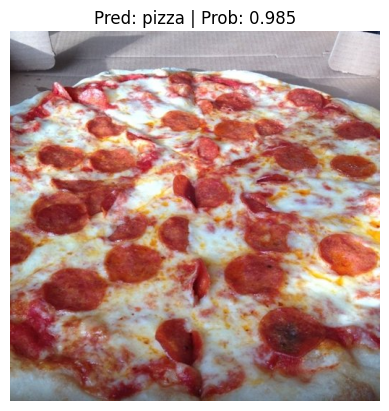

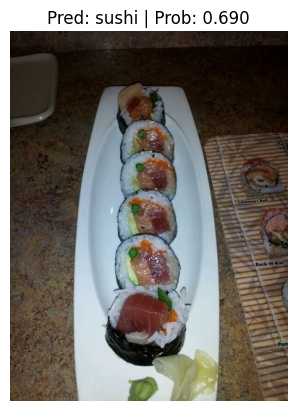

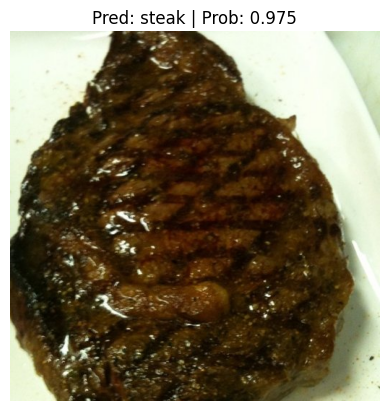

In [28]:
# make prediction on and plot the images
for image_path in test_image_path_sample:
  pred_and_plot_image(model=model,
                      image_path=image_path,
                      class_names=class_names,image_size=(224, 224))

Making a Prediction on a Custom Image

### 6.1 Making predictions on a custom image

Let's make a prediction from custom images

In [42]:
# Download the image
import requests

# Setup custom image path
custom_image_path = data_path / "pizza.jpg"
print(custom_image_path)
# Download the image if it doesn't exist
if not custom_image_path.is_file():
  with open(custom_image_path, 'wb') as f:
    # Download image from GitHub with 'raw' link
    # change blob to raw
    request = requests.get('https://github.com/sebastianperezv/PyTorch_DeepLearning/raw/f0c5ba77efe716b05895d3286eccc4d36ea22941/Transfer_learning/custom_images/pizza.jpg')
    print(f'Download {custom_image_path}...')
    f.write(request.content)
else:
  print(f'{custom_image_path} already exists, skipping download...')

data/pizza.jpg
Download data/pizza.jpg...


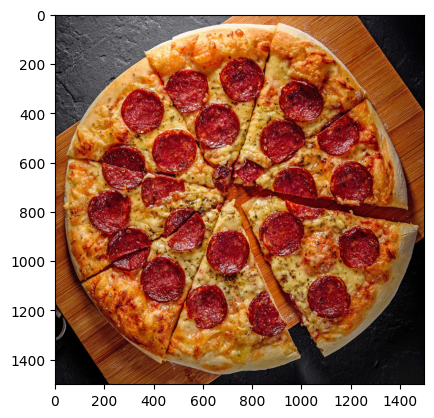

In [43]:
img = Image.open(custom_image_path)
plt.imshow(img)

tensor([[0.9797, 0.0047, 0.0156]], device='cuda:0')


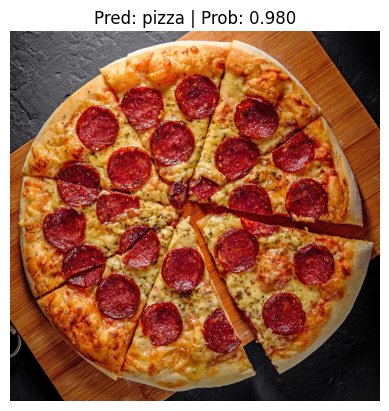

In [44]:
# Predict on custom image
pred_and_plot_image(model=model,
                    image_path=custom_image_path,
                    class_names=class_names)

# Main Takeaways

* transfer learning often allows to you get good results wit relatively small amout of custom data
* Knowing the power of transfer learning, it's good idea to ask at the start of every problem, "does an existing well-performing model exist for my problem?"
* When using pretrained model, it's important that your custom data be formatted/preprocessed in the same way that the original model was trained on, otherwise you may get degraded performance
* The same goes for predicting on custom data, ensure your custom data is in the same format as the data your model was trained on
* There are several different places to find pretrained mdoels, from the PyTorch domain libraries, HuggingFace Hub and libraries such as timm (PyTorch Image Models)